# PolyBench GEMM filtering smoke test (0622 dsub)

Triad-only analysis derived from the 0617 filtering notebook. The input is discovered from the data pulled back to af309.


In [337]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [338]:
DATE_BASE = "20260624"
SHUFFLE_SELECT = "shuffle1"
# RUN_ID = os.environ.get("RUN_ID") or os.environ.get("TRIAD_RUN_ID") or "20260624-full-polybench-gemm-harnessfix-dsub_warm1000_ntest10"
# RUN_ID = os.environ.get("RUN_ID") or os.environ.get("TRIAD_RUN_ID") or "20260624-184730-polybench-gemm-dsub" # warm20_ntest200,noinline
# RUN_ID = os.environ.get("RUN_ID") or os.environ.get("TRIAD_RUN_ID") or  # cpuid all
RUN_ID = "20260624-cpuid-gemm-dsub"

DATA_BASE = Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}")


def discover_run_roots():
    roots = []
    for host_dir in sorted(DATA_BASE.iterdir()) if DATA_BASE.exists() else []:
        output_root = host_dir / "output_polybench_gemm_filt_dsub"
        if not output_root.exists():
            continue
        stamps = [output_root / RUN_ID] if RUN_ID else sorted(
            (p for p in output_root.iterdir() if p.is_dir()), reverse=True
        )
        for stamp in stamps:
            shuffle = stamp / SHUFFLE_SELECT
            if shuffle.exists():
                roots.append(shuffle)
                break
    if not roots:
        requested = RUN_ID or "latest available run"
        raise FileNotFoundError(f"No PolyBench GEMM data for {requested} under {DATA_BASE}")
    return roots


DATA_FOLDERS = discover_run_roots()
HOST_ORDER = [p.parts[p.parts.index('data') + 2] for p in DATA_FOLDERS]
# HOST_ORDER = ['cgnr6760pn2', 'camd9554n1', 'c920bn3']
RUN_ROOTS = [p.parent for p in DATA_FOLDERS]
SHUFFLE_LABEL = "_".join(f"{host}-{Path(root).name}" for host, root in zip(HOST_ORDER, DATA_FOLDERS))

QUANTILE_DROP = 1.0
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/stencil/plots_0624_full_polybench_gemm_dsub')

TIMER_COLORS = {
    'cgt': '#ff7f0e', 'clock_gettime': '#ff7f0e', 'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c', 'papi': '#d62728', 'papix6': '#9467bd',
    'likwid': '#8c564b', 'tsc': '#1f77b4', 'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf', 'cntvct': '#e377c2', 'cntvcto': '#e377c2',
}
TIMER_LABELS = {
    'tsc': 'TSC', 'tsc_fence': 'TSC_Fence', 'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime', 'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime', 'mpi_wtime': 'MPI_Wtime', 'papi': 'PAPI',
    'papix6': 'PAPIx6', 'likwid': 'LIKWID', 'cntvct': 'CNTVCT', 'cntvcto': 'CNTVCT',
}
KERNEL_LABELS = {'polybench_gemm': 'PolyBench GEMM'}
HOST_LABELS = {
    'cgnr6760pn2': 'Intel Xeon 6760P', 'camd9554n1': 'AMD EPYC 9554',
    'camd9554n2': 'AMD EPYC 9554', 'c920bn3': 'Kunpeng 920B',
}

for root in DATA_FOLDERS:
    print(root)
print("host_order:", HOST_ORDER)
print("shuffle_label:", SHUFFLE_LABEL)


/astrum/home/hpchzy/code/data/20260624/c920bn3/output_polybench_gemm_filt_dsub/20260624-cpuid-gemm-dsub/shuffle1
/astrum/home/hpchzy/code/data/20260624/camd9554n1/output_polybench_gemm_filt_dsub/20260624-cpuid-gemm-dsub/shuffle1
/astrum/home/hpchzy/code/data/20260624/cgnr6760pn2/output_polybench_gemm_filt_dsub/20260624-cpuid-gemm-dsub/shuffle1
host_order: ['c920bn3', 'camd9554n1', 'cgnr6760pn2']
shuffle_label: c920bn3-shuffle1_camd9554n1-shuffle1_cgnr6760pn2-shuffle1


In [339]:
def parse_filt_dir(path):
    m = re.match(r'(?P<prefix>.+)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<nsampRatio>[\d.]+)_nsamp(?P<nsamp>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    prefix = d.pop('prefix')
    kernel = None
    timer = None
    for candidate in sorted(TIMER_LABELS, key=len, reverse=True):
        suffix = f'_{candidate}'
        if prefix.endswith(suffix):
            kernel = prefix[:-len(suffix)]
            timer = candidate
            break
    if not kernel or not timer:
        return None
    d['kernel'] = kernel
    d['timer'] = timer
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    d['nsamp'] = int(d['nsamp'])
    d['nsampRatio'] = float(d['nsampRatio'])
    return d


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cntvct', 'cntvcto', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    """Read tr_hist.csv as piecewise-linear CDF.

    Format: (left_edge, prob) per row; bin [t_i, t_{i+1}) has probability prob_i;
    last row is sentinel with prob=0 (right boundary).
    Returns df with cdf[i] = cumulative probability at LEFT edge of bin i,
    so plotting ns vs cdf gives a diagonal piecewise-linear CDF (not step function).
    """
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    cs = df['prob'].cumsum()
    # Keep bins whose LEFT edge starts below QUANTILE_DROP, plus one right-boundary row.
    left_cdf = cs.shift(1, fill_value=0.0)
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        iloc_last = df.index.get_loc(keep[keep].index[-1])
        if iloc_last + 1 < len(df):
            keep.iloc[iloc_last + 1] = True
    df = df[keep].copy()
    # cdf[i] = CDF at left edge of bin i = sum of probs of all PREVIOUS bins
    df['cdf'] = df['prob'].cumsum().shift(1, fill_value=0.0)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
entries = entries[entries['kernel'] == 'polybench_gemm'].copy()
if entries.empty:
    raise RuntimeError('No polybench_gemm filtered entries found')
print(f'entries: {len(entries)}')
entries.sort_values(['host', 'kernel', 'np', 'size', 'timer']).head(20)
entries = entries[(entries['timer'] != 'tsc_native') & (entries['timer'] != 'cntvct')]
entries['timer'] = entries['timer'].replace('cntvcto', 'cntvct')
# entries = entries[(entries['timer'] != 'papi') & (entries['timer'] != 'cgt')]


entries: 72


# ER/EP/Wasserstein

In [340]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


def read_hist_for_sampling(hist_file):
    """Read (lb, pr) histogram into (lb, rb, pr) DataFrame for quantile sampling."""
    try:
        tmp = pd.read_csv(hist_file, header=None, names=['lb', 'pr'])
    except Exception:
        return None
    tmp['lb'] = pd.to_numeric(tmp['lb'], errors='coerce')
    tmp['pr'] = pd.to_numeric(tmp['pr'], errors='coerce').fillna(0.0)
    tmp = tmp.dropna(subset=['lb']).reset_index(drop=True)
    m = ~np.isclose(tmp['pr'], 0)
    if not m.any():
        return None
    last_nz = int(np.where(m)[0][-1])
    if last_nz + 1 >= len(tmp):
        return None
    tmp = tmp.iloc[:last_nz + 2].copy()
    tmp['rb'] = tmp['lb'].shift(-1)
    tmp['lb'] = tmp['lb'].astype(np.float64)
    tmp = tmp[['lb', 'rb', 'pr']].iloc[:-1].dropna()
    return tmp if not tmp.empty else None


def sample_from_bins_quantile(tmp_df, n=1000):
    lb = tmp_df['lb'].to_numpy()
    rb = tmp_df['rb'].to_numpy()
    pr = tmp_df['pr'].to_numpy()
    pr = pr / pr.sum()
    p0 = np.r_[0, np.cumsum(pr)]
    q = (np.arange(n) + 0.5) / n
    idx = np.searchsorted(p0[1:], q, side='right')
    local_t = (q - p0[idx]) / pr[idx]
    return lb[idx] + local_t * (rb[idx] - lb[idx])


SEQ_N = 1000

summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')
    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")
    _tr_h = read_hist_for_sampling(filt_folder / 'tr_hist.csv')
    _tm_h = read_hist_for_sampling(filt_folder / 'tm_hist.csv')
    tr_seq = sample_from_bins_quantile(_tr_h, SEQ_N) if _tr_h is not None else None
    tm_seq = sample_from_bins_quantile(_tm_h, SEQ_N) if _tm_h is not None else None
    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd, 'tr_seq': tr_seq, 'tm_seq': tm_seq})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['host', 'kernel', 'np', 'size', 'timer'], inplace=True)

df = df[~df['kernel'].str.contains('tsc')]

df[['host', 'kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)  # tr_seq/tm_seq stored as object columns


,host,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
2,c920bn3,polybench_gemm,cgt,64,32,0.000000,0.007952,6.102513,0.000000,0.000000
6,c920bn3,polybench_gemm,cntvct,64,32,0.000000,0.004962,3.777889,0.000000,0.000000
10,c920bn3,polybench_gemm,papi,64,32,0.027482,0.005143,4.623116,8.516428,8.516430
14,c920bn3,polybench_gemm,papix6,64,32,0.000834,0.004575,4.211055,9.993154,9.993140
18,c920bn3,polybench_gemm,wtime,64,32,0.003043,0.005376,4.131658,8.947086,8.947080
3,c920bn3,polybench_gemm,cgt,64,64,0.006232,0.002856,8.342714,10.561218,10.561219
7,c920bn3,polybench_gemm,cntvct,64,64,0.007386,0.002375,6.919598,3.557868,3.557870
11,c920bn3,polybench_gemm,papi,64,64,0.013912,0.002137,6.530653,8.524696,8.524690
15,c920bn3,polybench_gemm,papix6,64,64,0.002257,0.001622,4.993970,17.918743,17.918762
19,c920bn3,polybench_gemm,wtime,64,64,0.010575,0.002144,6.264322,3.269013,3.269020


In [341]:
print('kernels:', sorted(df['kernel'].unique()))
print(df[['host', 'kernel', 'timer', 'np', 'size', 'nsampRatio', 'ep', 'er', 'wd']])


kernels: ['polybench_gemm']
           host          kernel   timer  np  size  nsampRatio        ep  \
2       c920bn3  polybench_gemm     cgt  64    32         0.5  0.000000   
6       c920bn3  polybench_gemm  cntvct  64    32         0.5  0.000000   
10      c920bn3  polybench_gemm    papi  64    32         0.5  0.027482   
14      c920bn3  polybench_gemm  papix6  64    32         0.5  0.000834   
18      c920bn3  polybench_gemm   wtime  64    32         0.5  0.003043   
3       c920bn3  polybench_gemm     cgt  64    64         0.5  0.006232   
7       c920bn3  polybench_gemm  cntvct  64    64         0.5  0.007386   
11      c920bn3  polybench_gemm    papi  64    64         0.5  0.013912   
15      c920bn3  polybench_gemm  papix6  64    64         0.5  0.002257   
19      c920bn3  polybench_gemm   wtime  64    64         0.5  0.010575   
0       c920bn3  polybench_gemm     cgt  64   128         0.5  0.001448   
4       c920bn3  polybench_gemm  cntvct  64   128         0.5  0.005668 

In [342]:
# df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
# df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])

# df['shuffle'] = df['shuffle'].astype('string')
# df
# for k,v_df in df.groupby(['np','size','host','nsampRatio','nsamp','kernel','host','shuffle']):
#     print(k)
#     print(v_df.columns)

In [343]:
# Cross-timer divergence before (T_m) / after (T_r).
# A single-timer smoke run has no meaningful cross-timer comparison and is skipped explicitly.
from scipy.stats import wasserstein_distance

EP_THRESHOLD = 0.1
ER_THRESHOLD = 0.1
REF_TIMER_BY_HOST = {'cgnr6760pn2': 'tsc', 'camd9554n1': 'tsc', 'c920bn3': 'cntvct'}


def divergence_table(src, group_keys):
    rows = []
    for gv, group in src.groupby(group_keys):
        keys = gv if isinstance(gv, tuple) else (gv,)
        row = dict(zip(group_keys, keys))
        timers = list(group['timer'].dropna().unique())
        if len(timers) < 2:
            continue
        ref_timer = REF_TIMER_BY_HOST.get(row['host'])
        if ref_timer not in timers:
            ref_timer = sorted(timers, key=timer_sort_key)[0]
        ref = group[group['timer'] == ref_timer].iloc[0]
        ref_tm = np.asarray(ref['tm_seq'], dtype=float)
        base = float(np.mean(ref_tm)) if ref_tm.size else np.nan
        tm_dist, tr_dist = [], []
        for _, item in group[group['timer'] != ref_timer].iterrows():
            tm_dist.append(wasserstein_distance(item['tm_seq'], ref['tm_seq']))
            tr_dist.append(wasserstein_distance(item['tr_seq'], ref['tr_seq']))
        sum_tm, sum_tr = float(np.sum(tm_dist)), float(np.sum(tr_dist))
        row.update(
            d_before=np.mean(tm_dist) / base if base > 0 else np.nan,
            d_after=np.mean(tr_dist) / base if base > 0 else np.nan,
            reduction=(sum_tm - sum_tr) / sum_tm if sum_tm > 0 else np.nan,
        )
        rows.append(row)
    return pd.DataFrame(rows)


div_df = divergence_table(df, ['kernel', 'host', 'size', 'nsampRatio'])
if div_df.empty:
    print('SKIP cross-timer divergence: fewer than two timers are available for each smoke-test group.')
else:
    print(div_df)


            kernel         host  size  nsampRatio  d_before   d_after  \
0   polybench_gemm      c920bn3    32         0.5  0.099945  0.005572   
1   polybench_gemm      c920bn3    64         0.5  0.026816  0.005855   
2   polybench_gemm      c920bn3   128         0.5  0.009644  0.002250   
3   polybench_gemm      c920bn3   256         0.5  0.002793  0.000493   
4   polybench_gemm   camd9554n1    32         0.5  0.589006  0.018242   
5   polybench_gemm   camd9554n1    64         0.5  0.147506  0.002072   
6   polybench_gemm   camd9554n1   128         0.5  0.038359  0.000431   
7   polybench_gemm   camd9554n1   256         0.5  0.009972  0.001216   
8   polybench_gemm  cgnr6760pn2    32         0.5  0.336304  0.195286   
9   polybench_gemm  cgnr6760pn2    64         0.5  0.046529  0.035655   
10  polybench_gemm  cgnr6760pn2   128         0.5  0.026334  0.013941   
11  polybench_gemm  cgnr6760pn2   256         0.5  0.006024  0.004569   

    reduction  
0    0.944254  
1    0.781664  
2 

In [344]:
if div_df.empty:
    print('SKIP divergence ranking: no cross-timer result.')
else:
    display(div_df.sort_values('reduction', ascending=False))


,kernel,host,size,nsampRatio,d_before,d_after,reduction
6,polybench_gemm,camd9554n1,128,0.5,0.038359,0.000431,0.988774
5,polybench_gemm,camd9554n1,64,0.5,0.147506,0.002072,0.985955
4,polybench_gemm,camd9554n1,32,0.5,0.589006,0.018242,0.969029
0,polybench_gemm,c920bn3,32,0.5,0.099945,0.005572,0.944254
7,polybench_gemm,camd9554n1,256,0.5,0.009972,0.001216,0.878019
3,polybench_gemm,c920bn3,256,0.5,0.002793,0.000493,0.823529
1,polybench_gemm,c920bn3,64,0.5,0.026816,0.005855,0.781664
2,polybench_gemm,c920bn3,128,0.5,0.009644,0.002250,0.766672
10,polybench_gemm,cgnr6760pn2,128,0.5,0.026334,0.013941,0.470596
8,polybench_gemm,cgnr6760pn2,32,0.5,0.336304,0.195286,0.419317


In [345]:
# Per-kernel: grid sizes where ALL hosts' ALL timers satisfy ep <= EP_THRESHOLD and er <= ER_THRESHOLD.
print(f'Qualifying grid sizes (every host/timer has ep <= {EP_THRESHOLD:g} and er <= {ER_THRESHOLD:g}):')
for kernel in sorted(df['kernel'].dropna().unique()):
    kdf = df[df['kernel'] == kernel]
    good = []
    for size, sdf in kdf.groupby('size'):
        if (sdf['ep'] <= EP_THRESHOLD).all() and (sdf['er'] <= ER_THRESHOLD).all():
            good.append(int(size))
    print(f'  {KERNEL_LABELS.get(kernel, kernel)} ({kernel}): {sorted(good)}')

Qualifying grid sizes (every host/timer has ep <= 0.1 and er <= 0.1):
  PolyBench GEMM (polybench_gemm): [32, 64, 128, 256]


# Filt Plot

In [346]:
entries['nsamp'].unique()

array([16647, 66024,  1116,  4234, 16617, 65975,  1102,  4219, 16893,
       66283,  1305,  4423, 16908, 66299,  1334,  4466, 66022, 12576,
       50091,   835,  3217, 13473, 51018,  1779,  4114, 13489, 51064,
       12545, 50058,   818,  3186, 12574, 50103, 13005, 49999,  1382,
        3707, 12515, 49701,  1002,  3801, 49663,  3810, 12257, 49574,
         797,  3624, 12279, 49397,   805,  3631])

[FILT CDF]  kernel=PolyBench GEMM  c920bn3-shuffle1_camd9554n1-shuffle1_cgnr6760pn2-shuffle1  np=64  size=32  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=765.50 ns  tr_median=725.50 ns
host=c920bn3 timer=cgt  tm_median=766.00 ns  tr_median=716.00 ns
host=c920bn3 timer=wtime  tm_median=773.41 ns  tr_median=724.41 ns
host=c920bn3 timer=papi  tm_median=904.13 ns  tr_median=724.13 ns
host=c920bn3 timer=papix6  tm_median=924.21 ns  tr_median=724.21 ns
host=camd9554n1 timer=tsc  tm_median=535.72 ns  tr_median=515.72 ns
host=camd9554n1 timer=cgt  tm_median=546.00 ns  tr_median=512.44 ns
host=camd9554n1 timer=wtime  tm_median=546.04 ns  tr_median=512.84 ns
host=camd9554n1 timer=papi  tm_median=1155.28 ns  tr_median=534.28 ns
host=camd9554n1 timer=papix6  tm_median=1159.94 ns  tr_median=529.94 ns
host=cgnr6760pn2 timer=tsc  tm_median=725.09 ns  tr_median=679.47 ns
host=cgnr6760pn2 timer=cgt  tm_median=1225.04 ns  tr_medi

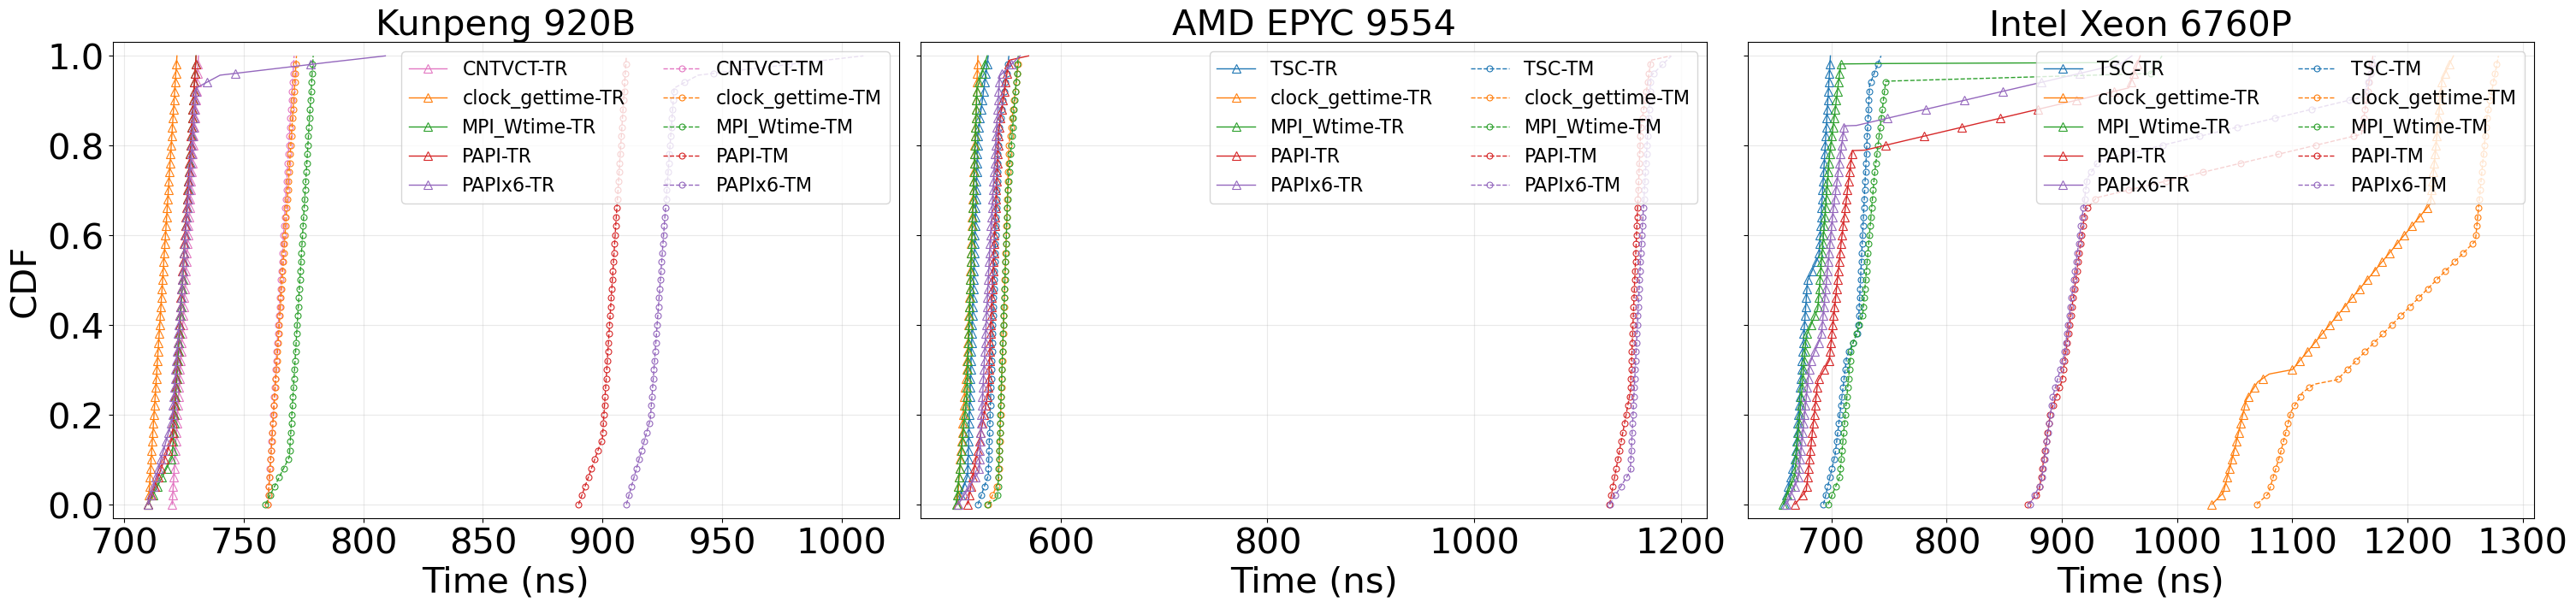

[FILT CDF]  kernel=PolyBench GEMM  c920bn3-shuffle1_camd9554n1-shuffle1_cgnr6760pn2-shuffle1  np=64  size=64  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=2917.76 ns  tr_median=2857.76 ns
host=c920bn3 timer=cgt  tm_median=2925.32 ns  tr_median=2844.32 ns
host=c920bn3 timer=wtime  tm_median=2920.95 ns  tr_median=2840.95 ns
host=c920bn3 timer=papi  tm_median=3056.24 ns  tr_median=2837.24 ns
host=c920bn3 timer=papix6  tm_median=3080.98 ns  tr_median=2840.98 ns
host=camd9554n1 timer=tsc  tm_median=2072.18 ns  tr_median=2051.17 ns
host=camd9554n1 timer=cgt  tm_median=2085.56 ns  tr_median=2054.51 ns
host=camd9554n1 timer=wtime  tm_median=2086.57 ns  tr_median=2056.16 ns
host=camd9554n1 timer=papi  tm_median=2666.75 ns  tr_median=2046.75 ns
host=camd9554n1 timer=papix6  tm_median=2672.20 ns  tr_median=2051.20 ns
host=cgnr6760pn2 timer=tsc  tm_median=3295.05 ns  tr_median=3249.42 ns
host=cgnr6760pn2 timer=cgt  tm_median

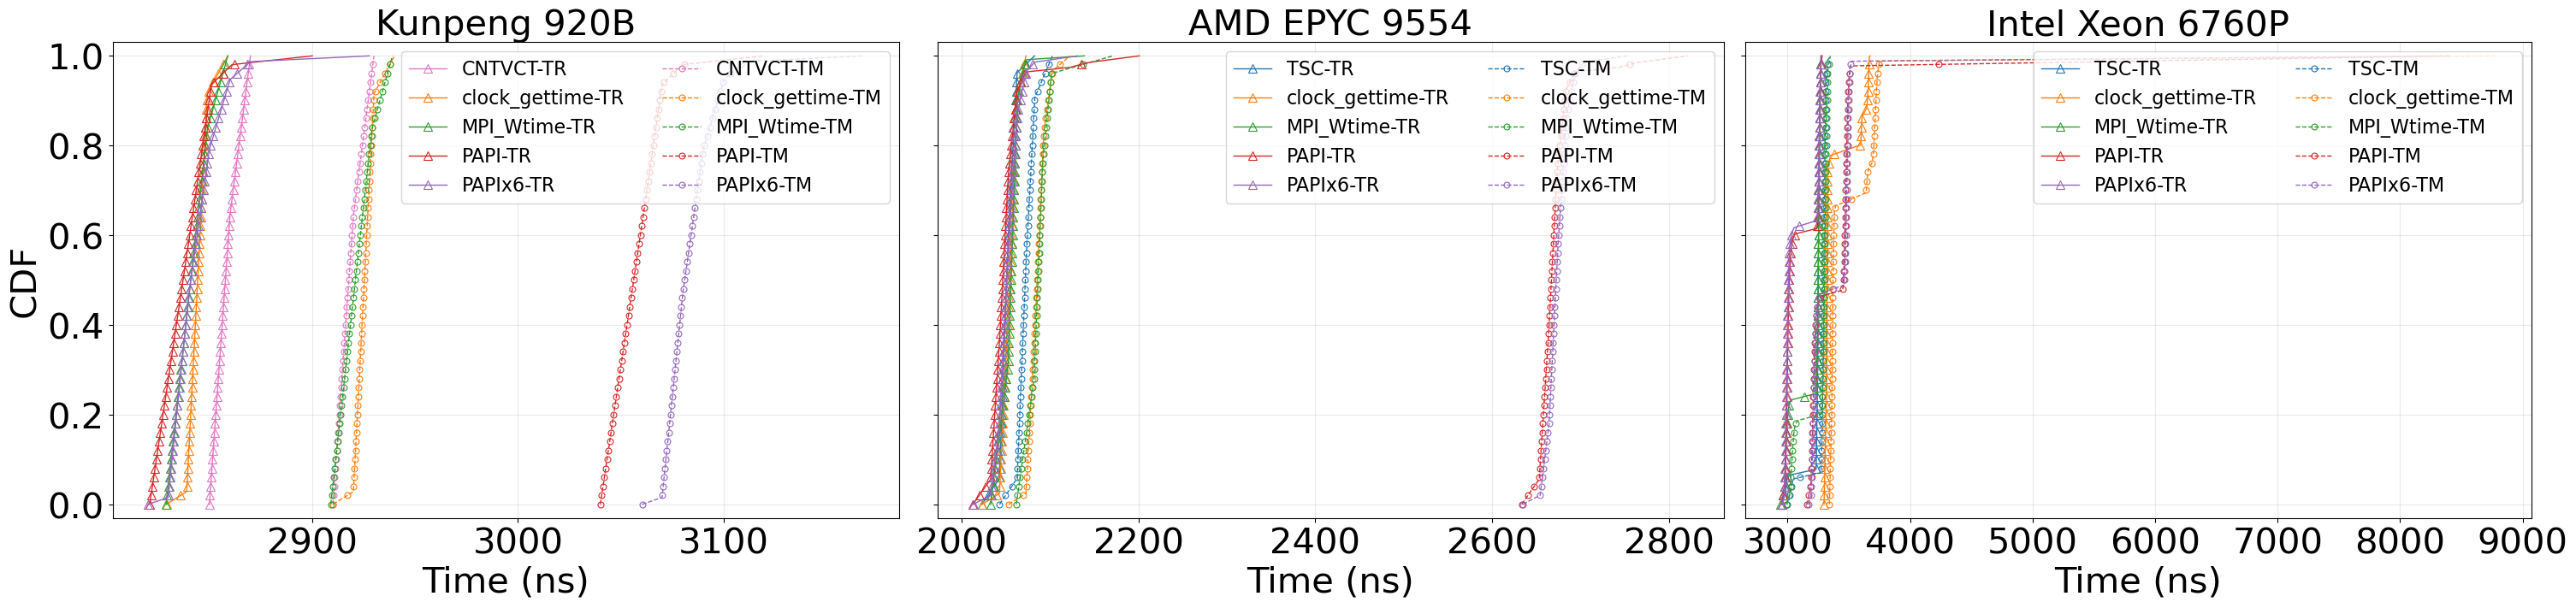

[FILT CDF]  kernel=PolyBench GEMM  c920bn3-shuffle1_camd9554n1-shuffle1_cgnr6760pn2-shuffle1  np=64  size=128  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=11463.27 ns  tr_median=11233.27 ns
host=c920bn3 timer=cgt  tm_median=11484.31 ns  tr_median=11244.31 ns
host=c920bn3 timer=wtime  tm_median=11483.74 ns  tr_median=11244.74 ns
host=c920bn3 timer=papi  tm_median=11652.90 ns  tr_median=11272.90 ns
host=c920bn3 timer=papix6  tm_median=11669.02 ns  tr_median=11269.02 ns
host=camd9554n1 timer=tsc  tm_median=8130.04 ns  tr_median=8114.65 ns
host=camd9554n1 timer=cgt  tm_median=8144.56 ns  tr_median=8118.59 ns
host=camd9554n1 timer=wtime  tm_median=8139.05 ns  tr_median=8115.53 ns
host=camd9554n1 timer=papi  tm_median=8726.35 ns  tr_median=8118.06 ns
host=camd9554n1 timer=papix6  tm_median=8736.32 ns  tr_median=8116.51 ns
host=cgnr6760pn2 timer=tsc  tm_median=11143.30 ns  tr_median=11022.90 ns
host=cgnr6760pn2 timer=c

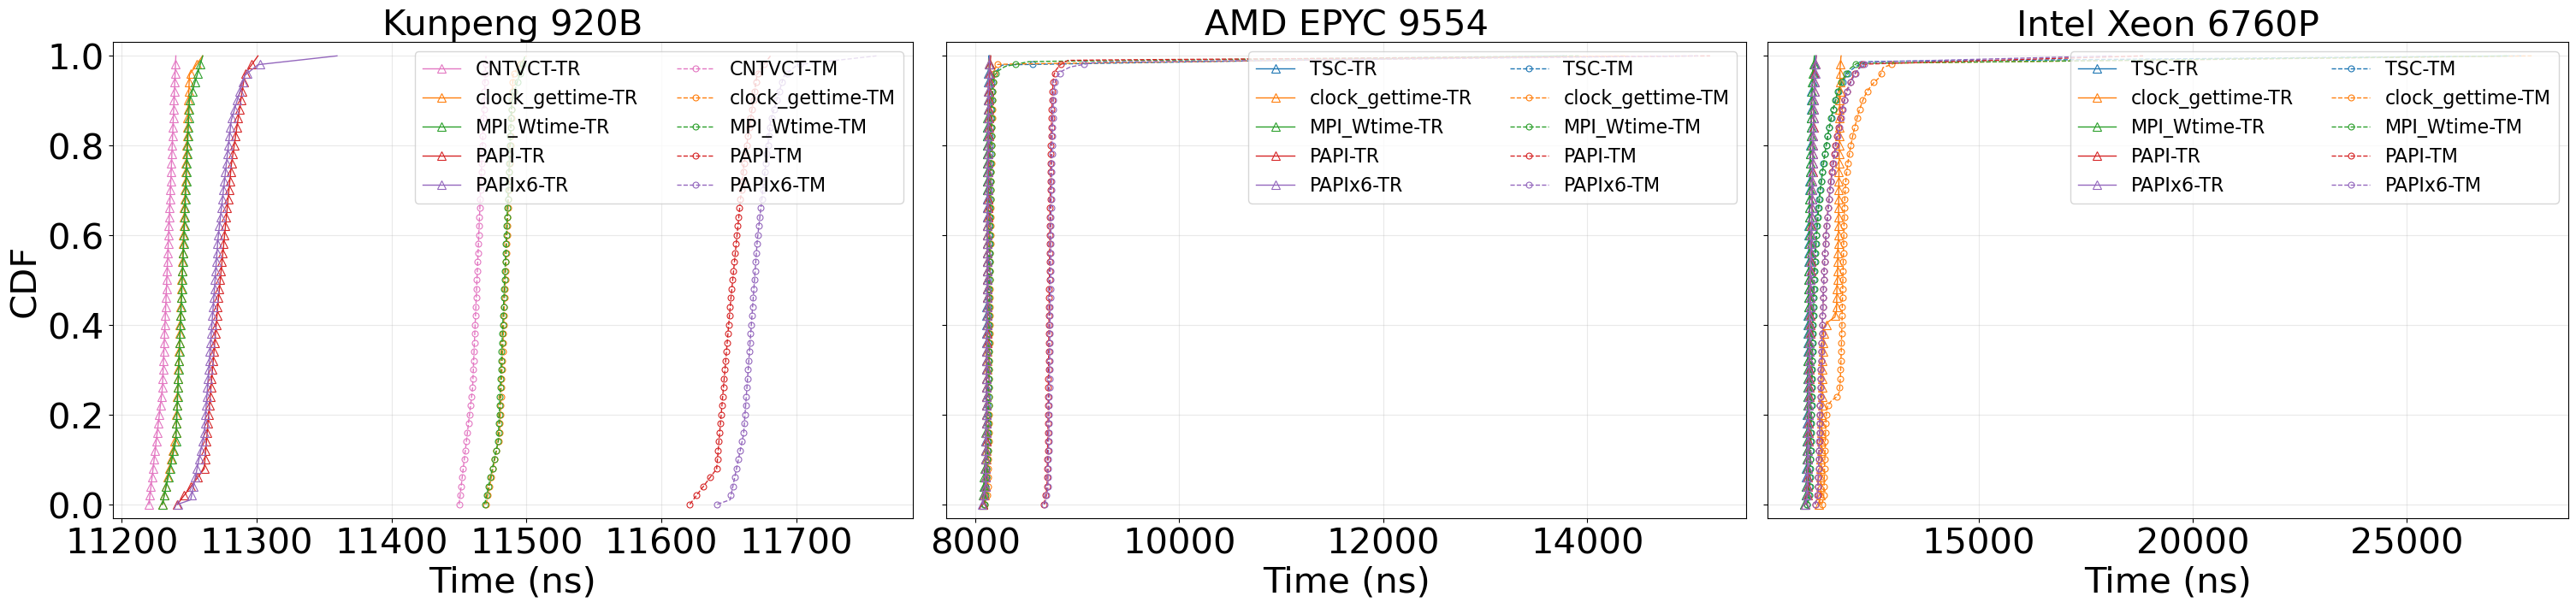

[FILT CDF]  kernel=PolyBench GEMM  c920bn3-shuffle1_camd9554n1-shuffle1_cgnr6760pn2-shuffle1  np=64  size=256  nsampRatio=0.5  hosts(L->R)=['Kunpeng 920B', 'AMD EPYC 9554', 'Intel Xeon 6760P']
host=c920bn3 timer=cntvct  tm_median=45509.62 ns  tr_median=44664.26 ns
host=c920bn3 timer=cgt  tm_median=45538.85 ns  tr_median=44635.65 ns
host=c920bn3 timer=wtime  tm_median=45538.27 ns  tr_median=44680.28 ns
host=c920bn3 timer=papi  tm_median=45715.43 ns  tr_median=44682.73 ns
host=c920bn3 timer=papix6  tm_median=45730.98 ns  tr_median=44688.34 ns
host=camd9554n1 timer=tsc  tm_median=32416.83 ns  tr_median=32442.97 ns
host=camd9554n1 timer=cgt  tm_median=32436.23 ns  tr_median=32459.16 ns
host=camd9554n1 timer=wtime  tm_median=32434.45 ns  tr_median=32455.08 ns
host=camd9554n1 timer=papi  tm_median=33031.96 ns  tr_median=32396.05 ns
host=camd9554n1 timer=papix6  tm_median=33058.21 ns  tr_median=32419.06 ns
host=cgnr6760pn2 timer=tsc  tm_median=45064.92 ns  tr_median=44727.40 ns
host=cgnr6760p

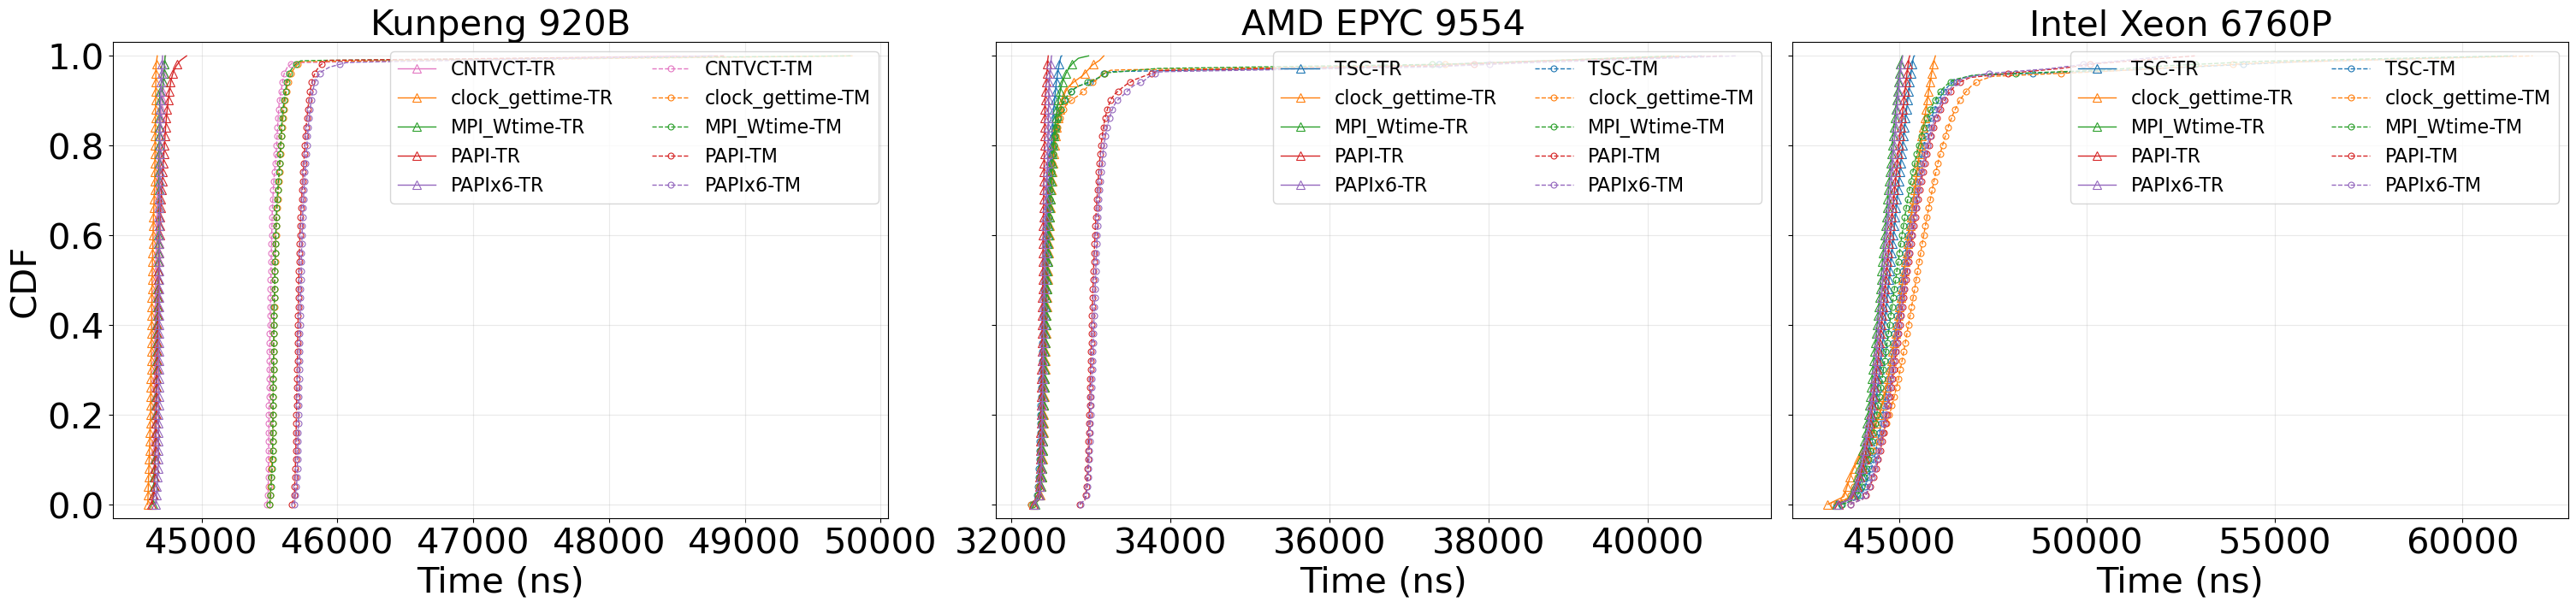

In [347]:
# ---- font sizes (tune here) ----
FILT_TITLE_FONTSIZE  = 30
FILT_LABEL_FONTSIZE  = 30
FILT_TICK_FONTSIZE   = 30
FILT_LEGEND_FONTSIZE = 16

plot_df = df[df['timer'] != 'likwid'].copy()

if plot_df.empty:
    raise RuntimeError('No entries with tr_seq/tm_seq to plot')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]


def seq_ecdf(seq):
    """ECDF (x, y) from a sample array, clipped to QUANTILE_DROP."""
    s = np.sort(np.asarray(seq, dtype=float))
    n = s.size
    if n == 0:
        return s, s
    y = (np.arange(n) + 0.5) / n
    keep = y <= QUANTILE_DROP
    return s[keep], y[keep]


def _ordered_tr_tm(ax):
    """Legend handles ordered so each row pairs timer-TR, timer-TM (ncol=2, column-major)."""
    h, l = ax.get_legend_handles_labels()
    tr = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TR')]
    tm = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TM')]
    ordered = tr + tm
    return [hh for hh, ll in ordered], [ll for hh, ll in ordered]


for (kernel, np_val, size, nsamp_ratio), group_all in plot_df.groupby(['kernel', 'np', 'size', 'nsampRatio'], sort=True):
    if kernel != 'polybench_gemm':
        continue

    print(f'[FILT CDF]  kernel={KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_LABEL}  np={np_val}  size={size}  nsampRatio={nsamp_ratio}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}')
    fig, axes = plt.subplots(1, len(hosts), figsize=(10.0 * len(hosts), 7), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    for ax, host in zip(axes, hosts):
        group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))

        for _, row in group.iterrows():
            timer = row['timer']
            color = TIMER_COLORS.get(timer)
            label = timer_label(timer)

            if row['tm_seq'] is None or row['tr_seq'] is None:
                continue

            tm_x, tm_y = seq_ecdf(row['tm_seq'])
            tr_x, tr_y = seq_ecdf(row['tr_seq'])

            row['tm_median'] = np.median(row['tm_seq'])
            row['tr_median'] = np.median(row['tr_seq'])
            print(f"host={row['host']} timer={row['timer']}  tm_median={row['tm_median']:.2f} ns  tr_median={row['tr_median']:.2f} ns")

            tm_me = max(1, len(tm_x) // 50)
            tr_me = max(1, len(tr_x) // 50)

            ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, marker='.', markevery=tm_me, markersize=10, markerfacecolor='none', markeredgewidth=0.8)
            ax.plot(tr_x, tr_y, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, marker='^', markevery=tr_me, markersize=7, markerfacecolor='none', markeredgewidth=0.8)

        ax.set_title(f"{HOST_LABELS.get(host, host)}", fontsize=FILT_TITLE_FONTSIZE)
        ax.set_xlabel('Time (ns)', fontsize=FILT_LABEL_FONTSIZE)
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)
        ax.grid(True, alpha=0.28)
        ax.tick_params(axis='both', labelsize=FILT_TICK_FONTSIZE)
        oh, ol = _ordered_tr_tm(ax)
        if oh:
            ax.legend(oh, ol, ncol=2, fontsize=FILT_LEGEND_FONTSIZE, loc='upper right')

    for ax in axes:
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)

    axes[0].set_ylabel('CDF', fontsize=FILT_LABEL_FONTSIZE)

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_np{np_val}_size{size}_ratio{nsamp_ratio}_tm_tr_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()
